<img src="https://drive.google.com/uc?export=view&id=14reVO1X6LsjqJ3cFgoeHxxddZVGfZn3t" width="100%">

# Evaluación del modelo final

Este notebook realiza la evaluación del modelo final seleccionado en la etapa de modelamiento. Para ello se recuperan tanto el modelo exportado como las particiones de entrenamiento, validación y prueba previamente definidas, garantizando que la evaluación se haga sobre el mismo diseño experimental usado durante el entrenamiento.

El objetivo de esta fase es describir de manera detallada el rendimiento del modelo final mediante métricas globales, métricas ponderadas por clase y herramientas de análisis como el reporte de clasificación y la matriz de confusión.

In [10]:
!pip install -q gdown

In [18]:
import os
import zipfile
import shutil
from glob import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gdown
import sys

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## 1. Recuperación de artefactos del proyecto

En esta sección se accede al repositorio del proyecto y se cargan los artefactos generados en la fase de modelamiento: el archivo comprimido con las particiones y el archivo del modelo final entrenado. Esta separación entre artefactos de entrenamiento y evaluación favorece las buenas prácticas de versionado y reproducibilidad.

Desde la perspectiva de una futura puesta en producción, esta organización también simula un flujo más cercano a un entorno real, en el que el modelo serializado y los datos de referencia se consumen de manera desacoplada respecto al notebook de entrenamiento.

In [13]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

ZIP_PATH = "/content/dataset_limpio.zip"
EXTRACT_DIR = "/content/extracted_dataset"
OUTPUT_DIR = "/content/output_evaluacion"

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [14]:
dataset_url = "https://drive.google.com/file/d/1jGgN6t9Me6SlNvE0xsoK6Lzlh1-0v6Fr/view?usp=drive_link"

gdown.download(dataset_url, ZIP_PATH, fuzzy=True, quiet=False)

size_mb = os.path.getsize(ZIP_PATH) / (1024**2)
print(f"Tamaño descargado: {size_mb:.2f} MB")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracción completada.")

Downloading...
From: https://drive.google.com/uc?id=1jGgN6t9Me6SlNvE0xsoK6Lzlh1-0v6Fr
To: /content/dataset_limpio.zip
100%|██████████| 6.21M/6.21M [00:00<00:00, 37.9MB/s]


Tamaño descargado: 5.92 MB
Extracción completada.


In [15]:
def find_dataset_root(base_dir, min_class_folders=2):
    candidates = []

    for root, dirs, files in os.walk(base_dir):
        subdirs = [d for d in dirs if not d.startswith(".") and d != "__MACOSX"]
        if len(subdirs) >= min_class_folders:
            valid_subdirs = 0
            for d in subdirs:
                class_path = os.path.join(root, d)
                images = glob(os.path.join(class_path, "*.jpg"))
                images += glob(os.path.join(class_path, "*.jpeg"))
                images += glob(os.path.join(class_path, "*.png"))
                if len(images) > 0:
                    valid_subdirs += 1
            if valid_subdirs >= min_class_folders:
                candidates.append(root)

    candidates = sorted(set(candidates), key=lambda x: len(x))
    return candidates[0] if candidates else None

DATA_DIR = find_dataset_root(EXTRACT_DIR)

if DATA_DIR is None:
    raise ValueError("No se encontró una carpeta válida de dataset con subcarpetas de clases e imágenes.")

print("Ruta raíz del dataset detectada:")
print(DATA_DIR)
print("Subcarpetas encontradas:", os.listdir(DATA_DIR))

Ruta raíz del dataset detectada:
/content/extracted_dataset/content/dataset_limpio
Subcarpetas encontradas: ['jose', 'juan', 'nicolas']


In [16]:
for cls in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        imgs = glob(os.path.join(class_path, "*.jpg"))
        imgs += glob(os.path.join(class_path, "*.jpeg"))
        imgs += glob(os.path.join(class_path, "*.png"))
        print(f"{cls}: {len(imgs)} imágenes")

jose: 121 imágenes
juan: 90 imágenes
nicolas: 104 imágenes


In [8]:
!git clone https://github.com/josevitola/metodologias-2026.git

Cloning into 'metodologias-2026'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 107 (delta 1), reused 1 (delta 1), pack-reused 102 (from 2)
Receiving objects: 100% (107/107), 1.80 MiB | 3.93 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [19]:
# Ajusta esta ruta al nombre real de tu repositorio clonado en Colab
REPO_PATH = "/content/metodologias-2026/src/nombre_paquete/"

ZIP_PATH = os.path.join(REPO_PATH, "preprocessing", "particiones_dataset.zip")
EXTRACT_PATH = os.path.join(REPO_PATH, "preprocessing", "particiones_dataset")
MODEL_PATH = os.path.join(REPO_PATH, "models", "modelo_final_seleccionado.keras")
SCRIPTS_PATH = os.path.join(REPO_PATH, "evaluation")

sys.path.append(SCRIPTS_PATH)

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"No se encontró el archivo zip en: {ZIP_PATH}")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"No se encontró el modelo entrenado en: {MODEL_PATH}")

print("Archivo zip encontrado:", ZIP_PATH)
print("Modelo encontrado:", MODEL_PATH)

Archivo zip encontrado: /content/metodologias-2026/src/nombre_paquete/preprocessing/particiones_dataset.zip
Modelo encontrado: /content/metodologias-2026/src/nombre_paquete/models/modelo_final_seleccionado.keras


In [20]:
if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print("Contenido extraído en:", EXTRACT_PATH)
print(os.listdir(EXTRACT_PATH))

Contenido extraído en: /content/metodologias-2026/src/nombre_paquete/preprocessing/particiones_dataset
['test_df.csv', 'val_df.csv', 'train_df.csv']


## Reconstrucción de las particiones de evaluación

Las particiones de entrenamiento, validación y prueba se reconstruyen a partir de los archivos CSV exportados previamente. Esto asegura que el modelo sea evaluado exactamente sobre el conjunto de prueba reservado desde el inicio, sin alteraciones en la distribución de datos ni filtraciones de información entre etapas.

Posteriormente se recrean los generadores de imágenes con el mismo preprocesamiento utilizado por EfficientNetB0. La consistencia entre entrenamiento y evaluación es indispensable para que las métricas obtenidas sean comparables y metodológicamente válidas.

In [21]:
TRAIN_CSV = os.path.join(REPO_PATH, "preprocessing", "particiones_dataset", "train_df.csv")
VAL_CSV   = os.path.join(REPO_PATH, "preprocessing", "particiones_dataset", "val_df.csv")
TEST_CSV  = os.path.join(REPO_PATH, "preprocessing", "particiones_dataset", "test_df.csv")

print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

/content/metodologias-2026/src/nombre_paquete/preprocessing/particiones_dataset/train_df.csv
/content/metodologias-2026/src/nombre_paquete/preprocessing/particiones_dataset/val_df.csv
/content/metodologias-2026/src/nombre_paquete/preprocessing/particiones_dataset/test_df.csv


In [22]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (220, 2)
val_df: (47, 2)
test_df: (48, 2)


In [23]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print("Clases:", CLASS_NAMES)

Found 220 validated image filenames belonging to 3 classes.
Found 47 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Clases: ['jose', 'juan', 'nicolas']


In [24]:
X_batch, y_batch = next(test_generator)
print("Forma de X:", X_batch.shape)
print("Forma de y:", y_batch.shape)

Forma de X: (32, 224, 224, 3)
Forma de y: (32, 3)


## 2. Carga e inspección del modelo final

El modelo final exportado se carga desde disco y se inspecciona su arquitectura. Esta revisión permite verificar que la estructura utilizada en evaluación coincide con la configurada durante la etapa de modelamiento, incluyendo el backbone EfficientNetB0 y la cabeza clasificadora ajustada al problema de tres clases.

La inspección de parámetros entrenables y no entrenables también aporta evidencia de trazabilidad técnica, ya que permite documentar el tamaño y complejidad del modelo finalmente seleccionado.

In [25]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,886,766 (37.72 MB)

 Trainable params: 2,836,419 (10.82 MB)

 Non-trainable params: 1,377,507 (5.25 MB)

 Optimizer params: 5,672,840 (21.64 MB)

In [26]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 11s/step - accuracy: 0.8542 - loss: 0.3294
Loss en test: 0.3294
Accuracy en test: 0.8542


## Evaluación cuantitativa global

La primera evaluación del modelo se realiza mediante el método `evaluate` sobre el conjunto de prueba. En esta ejecución se obtiene una pérdida en test de 0.3294 y una exactitud de 0.8542, lo que indica un desempeño alto sobre datos no vistos durante el entrenamiento.

Estas métricas constituyen una estimación global del comportamiento del modelo final y complementan los resultados observados en validación durante la fase de modelamiento. Su función principal es verificar que el modelo conserve capacidad de generalización fuera del conjunto usado para ajustar hiperparámetros.

In [27]:
test_generator.reset()
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

y_true = test_generator.classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step


## Métricas de clasificación ponderadas

Además de la exactitud global, se generan predicciones sobre el conjunto de prueba para calcular métricas ponderadas de clasificación. Los resultados obtenidos fueron: `Accuracy = 0.854167`, `Precision ponderada = 0.865885`, `Recall ponderado = 0.854167` y `F1-score ponderado = 0.855090`.

El uso de métricas ponderadas es pertinente porque permite resumir el rendimiento multiclase considerando el peso relativo de cada categoría en el conjunto evaluado. Esto ofrece una visión más completa que la exactitud aislada, especialmente cuando se busca justificar de manera técnica el comportamiento del modelo final.

In [28]:
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision ponderada", "Recall ponderado", "F1-score ponderado"],
    "Valor": [acc, precision, recall, f1]
})

metrics_df

,Métrica,Valor
0,Accuracy,0.854167
1,Precision ponderada,0.865885
2,Recall ponderado,0.854167
3,F1-score ponderado,0.855090


## Reporte de clasificación por clase

El reporte de clasificación permite analizar el comportamiento del modelo para cada identidad de manera independiente, mediante precisión, recall y F1-score por clase. Este análisis es importante porque un buen desempeño global puede ocultar errores sistemáticos en clases específicas. [file:152]

Por tanto, esta sección complementa la evaluación global y permite identificar si existen categorías con mayor dificultad de reconocimiento, aspecto clave para interpretar correctamente el alcance y las limitaciones del sistema desarrollado. [file:152]

In [29]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
jose,0.937500,0.789474,0.857143,19.000000
juan,0.750000,0.923077,0.827586,13.000000
nicolas,0.875000,0.875000,0.875000,16.000000
accuracy,0.854167,0.854167,0.854167,0.854167
macro avg,0.854167,0.862517,0.853243,48.000000
weighted avg,0.865885,0.854167,0.855090,48.000000


In [30]:
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

              precision    recall  f1-score   support

        jose       0.94      0.79      0.86        19
        juan       0.75      0.92      0.83        13
     nicolas       0.88      0.88      0.88        16

    accuracy                           0.85        48
   macro avg       0.85      0.86      0.85        48
weighted avg       0.87      0.85      0.86        48



## Matriz de confusión

La matriz de confusión resume las predicciones correctas e incorrectas del modelo final en cada clase. Su lectura permite identificar no solo cuántos errores ocurren, sino entre qué clases se producen las confusiones más frecuentes.

Este análisis resulta especialmente útil en problemas de reconocimiento facial, ya que ayuda a determinar si el modelo está capturando rasgos discriminativos suficientes o si ciertas identidades presentan patrones visuales más difíciles de separar. En consecuencia, la matriz de confusión constituye una evidencia central dentro del reporte detallado del modelo final exigido por la rúbrica.

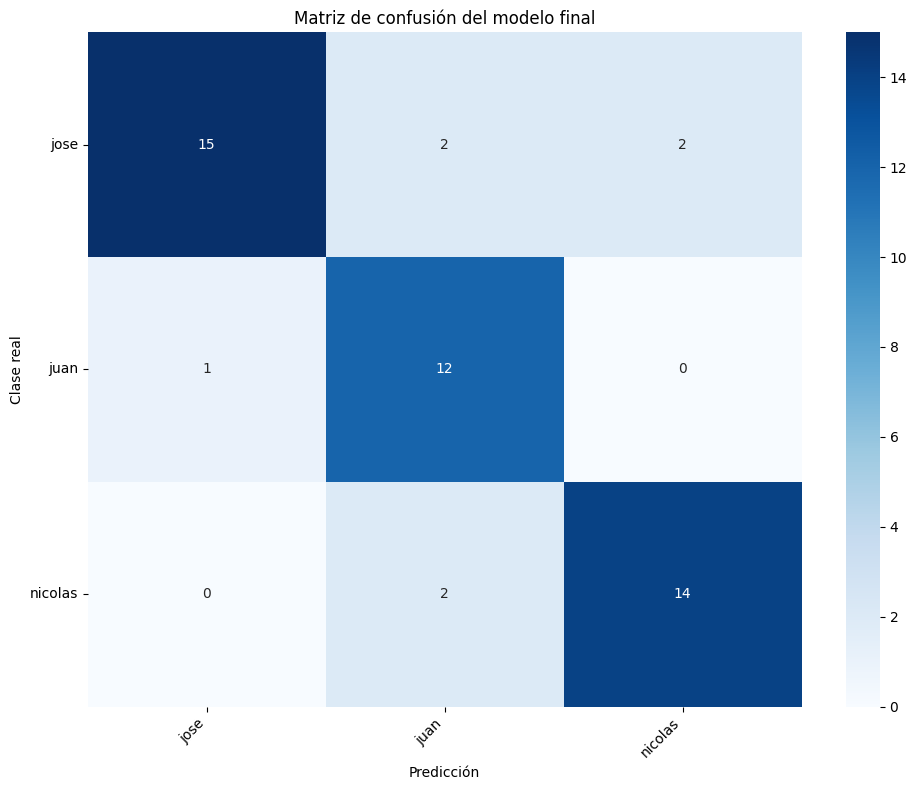

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión del modelo final")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

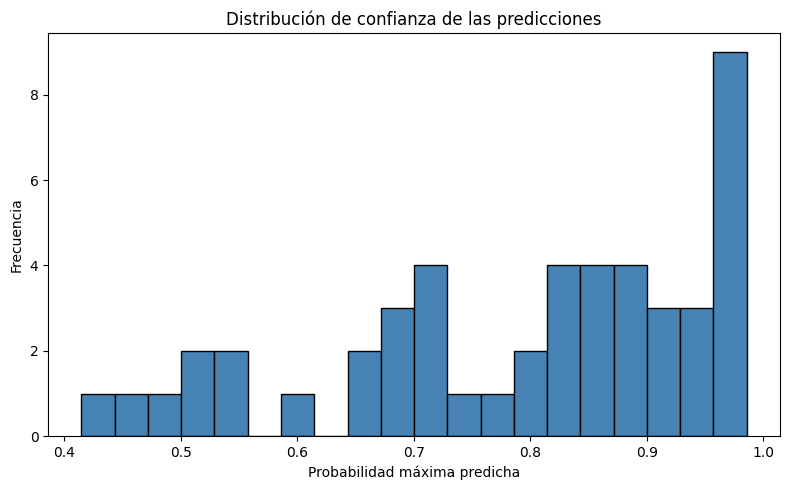

In [33]:
max_probs = np.max(y_prob, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20, color="steelblue", edgecolor="black")
plt.title("Distribución de confianza de las predicciones")
plt.xlabel("Probabilidad máxima predicha")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [34]:
results_df = test_df.copy().reset_index(drop=True)
results_df["y_true"] = y_true
results_df["y_pred"] = y_pred
results_df["true_class"] = [CLASS_NAMES[i] for i in y_true]
results_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]
results_df["confidence"] = max_probs
results_df["correcta"] = results_df["y_true"] == results_df["y_pred"]

results_df.head()

,filename,class,y_true,y_pred,true_class,pred_class,confidence,correcta
0,/content/extracted_dataset/content/dataset_lim...,jose,0,0,jose,jose,0.956954,True
1,/content/extracted_dataset/content/dataset_lim...,nicolas,2,2,nicolas,nicolas,0.944887,True
2,/content/extracted_dataset/content/dataset_lim...,juan,1,1,juan,juan,0.652510,True
3,/content/extracted_dataset/content/dataset_lim...,jose,0,0,jose,jose,0.977806,True
4,/content/extracted_dataset/content/dataset_lim...,juan,1,1,juan,juan,0.841979,True


In [37]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_df.to_csv(os.path.join(OUTPUT_DIR, "metricas_test.csv"), index=False)
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report.csv"))
results_df.to_csv(os.path.join(OUTPUT_DIR, "predicciones_test.csv"), index=False)

print("Resultados guardados en:", OUTPUT_DIR)

Resultados guardados en: /content/output_evaluacion


## Interpretación de resultados

El modelo final fue evaluado sobre la partición de prueba definida previamente en el proyecto. La evaluación incluye métricas globales, métricas por clase, matriz de confusión y revisión cualitativa de predicciones correctas e incorrectas.

Este cuaderno documenta de forma explícita el desempeño del modelo final seleccionado, en concordancia con el reporte de evaluación solicitado en la rúbrica.

* **Profesores:**
  - [Jorge E. Camargo, PhD](https://dis.unal.edu.co/~jecamargom/)
* **Asistentes docentes:**
    - [Juan Sebastián Malagón Torres](https://co.linkedin.com/in/juan-sebastian-malag%C3%B3n-torres-86039a164).
* **Diseño de imágenes:**
    - [Sebastián Daniel Moreno Martinez](http://www.linkedin.com/in/sm-xwx).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    